# Task 6: Image Classification Using Transfer Learning

## Objective
Develop an image classification model using Transfer Learning with MobileNetV2 to classify hand gesture images into three categories: Rock, Paper, and Scissors.

### Tools & Libraries
- Python
- TensorFlow / Keras
- NumPy
- Matplotlib

### Dataset
Rock-Paper-Scissors Image Dataset

In [3]:

import os
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
print("TensorFlow:", tf.__version__)



TensorFlow: 2.21.0


In [4]:
dataset_path = "dataset/rps-cv-images"

print("Classes:")

for folder in os.listdir(dataset_path):
    print(folder)

Classes:
paper
README_rpc-cv-images.txt
rock
scissors


In [6]:
for folder in os.listdir(dataset_path):

    folder_path = os.path.join(dataset_path, folder)

    print(f"{folder}: {len(os.listdir(folder_path))} images")

paper: 712 images
rock: 726 images
scissors: 750 images


In [7]:
img_height = 224
img_width = 224
batch_size = 32

train_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

Found 2188 files belonging to 3 classes.
Using 1751 files for training.
Found 2188 files belonging to 3 classes.
Using 437 files for validation.


In [8]:
class_names = train_dataset.class_names

print("Classes:", class_names)

Classes: ['paper', 'rock', 'scissors']


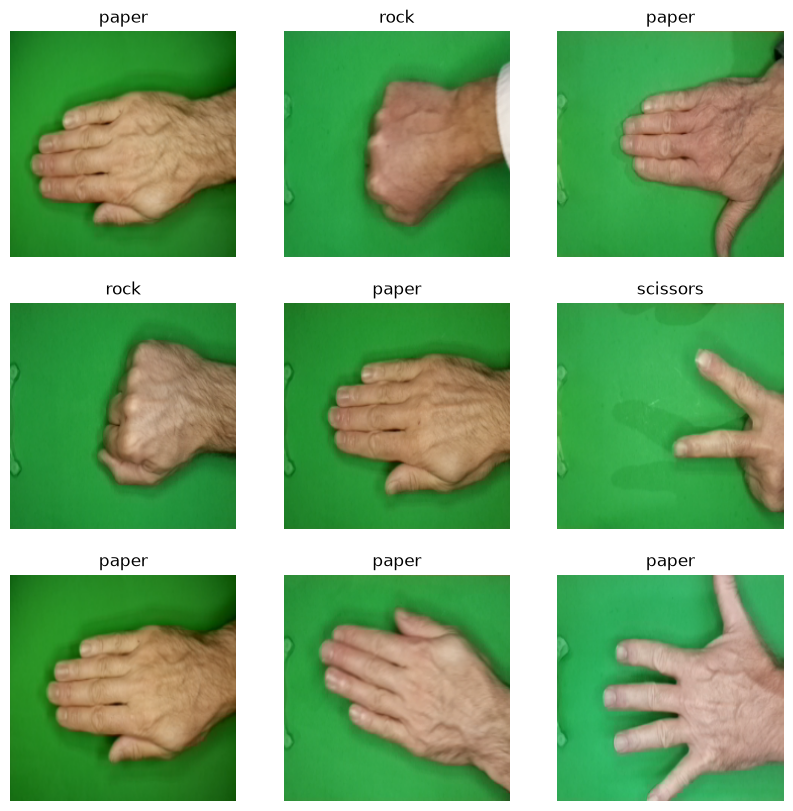

In [9]:
plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()


## Dataset
* The dataset contains 2,188 RGB images across three classes: Rock, Paper, and Scissors.
* Images are organized into separate class folders, making them suitable for supervised image classification.
  An 80:20 split was used for training and validation.

In [10]:

AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [13]:
base_model.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))

x = tf.keras.layers.Rescaling(1./255)(inputs)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(128, activation="relu")(x)
x = tf.keras.layers.Dropout(0.3)(x)

outputs = tf.keras.layers.Dense(len(class_names), activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)

In [14]:
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Data Preprocessing
All images were resized to 224 × 224 pixels, which matches the input size required by MobileNetV2.
Images were normalized before being passed to the neural network.
Batch loading was used to improve training efficiency.

## Model Selection
MobileNetV2 was selected as the base model because it is lightweight, fast, and well-suited for transfer learning.
Pre-trained ImageNet weights were used to leverage previously learned visual features.
The base model was frozen while only the custom classification layers were trained.

In [15]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=5
)

Epoch 1/5


C:\Users\Vighnesh\AppData\Roaming\Python\Python312\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


55/55 ━━━━━━━━━━━━━━━━━━━━ 38s 648ms/step - accuracy: 0.9143 - loss: 0.2247 - val_accuracy: 0.9863 - val_loss: 0.0425
Epoch 2/5
55/55 ━━━━━━━━━━━━━━━━━━━━ 33s 599ms/step - accuracy: 0.9891 - loss: 0.0319 - val_accuracy: 0.9954 - val_loss: 0.0189
Epoch 3/5
55/55 ━━━━━━━━━━━━━━━━━━━━ 33s 599ms/step - accuracy: 0.9960 - loss: 0.0164 - val_accuracy: 0.9954 - val_loss: 0.0199
Epoch 4/5
55/55 ━━━━━━━━━━━━━━━━━━━━ 34s 613ms/step - accuracy: 0.9983 - loss: 0.0088 - val_accuracy: 0.9954 - val_loss: 0.0113
Epoch 5/5
55/55 ━━━━━━━━━━━━━━━━━━━━ 34s 620ms/step - accuracy: 0.9983 - loss: 0.0068 - val_accuracy: 0.9954 - val_loss: 0.0090


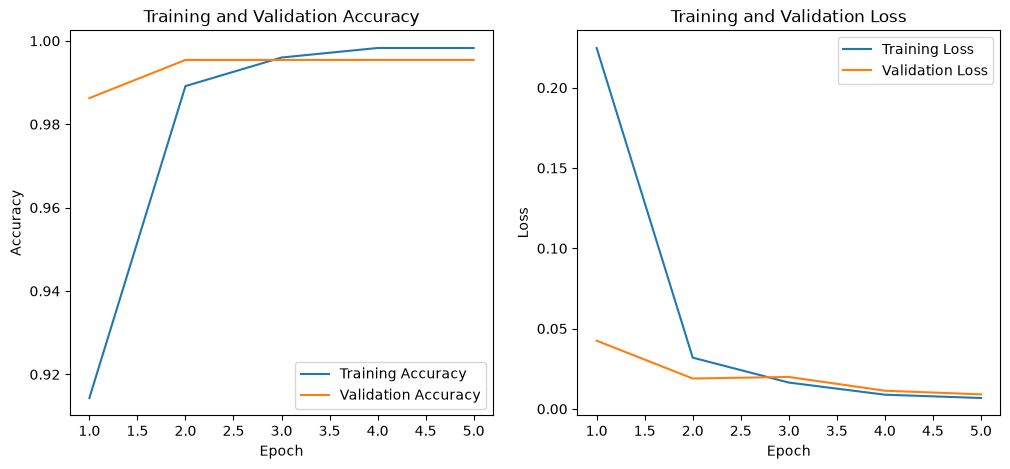

In [16]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs, acc, label='Training Accuracy')
plt.plot(epochs, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs, loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()



## Training Results
The model achieved very high training and validation accuracy after only a few epochs.
The small difference between training and validation accuracy indicates that the model generalized well without significant overfitting.

In [22]:
loss, accuracy = model.evaluate(validation_dataset)

print(f"Validation Accuracy: {accuracy*100:.2f}%")
print(f"Validation Loss: {loss:.4f}")

14/14 ━━━━━━━━━━━━━━━━━━━━ 7s 485ms/step - accuracy: 0.9954 - loss: 0.0090
Validation Accuracy: 99.54%
Validation Loss: 0.0090


## Final Performance
Training Accuracy: 99.83%
Validation Accuracy: 99.54%
Validation Loss: 0.0090

These results demonstrate that transfer learning is highly effective for this image classification task.

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 649ms/step


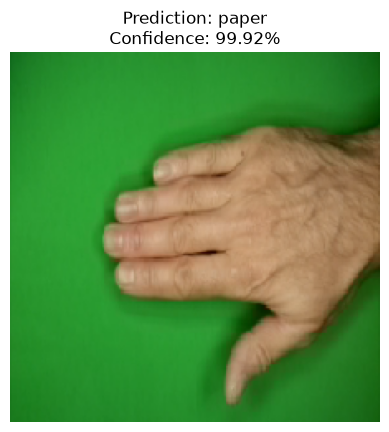

In [19]:
from tensorflow.keras.preprocessing import image

image_path = r"Dataset\rps-cv-images\paper\Ze6bn38U5XECyORF.png"

img = image.load_img(image_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

predicted_class = class_names[np.argmax(prediction)]
confidence = np.max(prediction)

plt.imshow(img)
plt.axis("off")
plt.title(f"Prediction: {predicted_class}\nConfidence: {confidence:.2%}")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


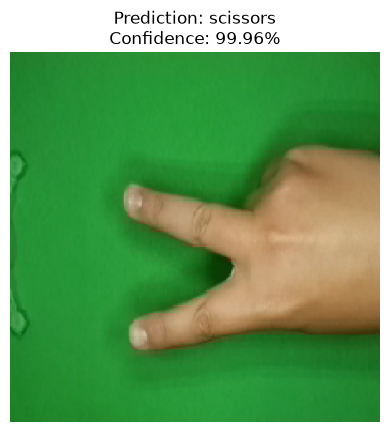

In [20]:

from tensorflow.keras.preprocessing import image

image_path = r"Dataset\rps-cv-images\scissors\1L1n6plr7jlZGirw.png"

img = image.load_img(image_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

predicted_class = class_names[np.argmax(prediction)]
confidence = np.max(prediction)

plt.imshow(img)
plt.axis("off")
plt.title(f"Prediction: {predicted_class}\nConfidence: {confidence:.2%}")
plt.show()

In [23]:
model.save("rock_paper_scissors_model.keras")

## Conclusion

A transfer learning approach using MobileNetV2 successfully classified Rock, Paper, and Scissors hand gestures with excellent accuracy while requiring only a small amount of training. The project demonstrates the effectiveness of deep learning and pre-trained convolutional neural networks for image classification tasks.